In [1]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [6]:
# Load processed datasets

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [7]:
rf_final = RandomForestClassifier(
    max_depth=8,
    min_samples_leaf=4,
    n_estimators=100,
    random_state=42
)

rf_final.fit(X_train, y_train.values.ravel())

RandomForestClassifier(max_depth=8, min_samples_leaf=4, random_state=42)

In [8]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_final.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,num__tenure,0.153562
36,cat__Contract_Month-to-month,0.115463
3,num__TotalCharges,0.108244
16,cat__InternetService_Fiber optic,0.070759
18,cat__OnlineSecurity_No,0.069292
2,num__MonthlyCharges,0.065530
43,cat__PaymentMethod_Electronic check,0.053098
27,cat__TechSupport_No,0.050863
38,cat__Contract_Two year,0.039230
21,cat__OnlineBackup_No,0.022077


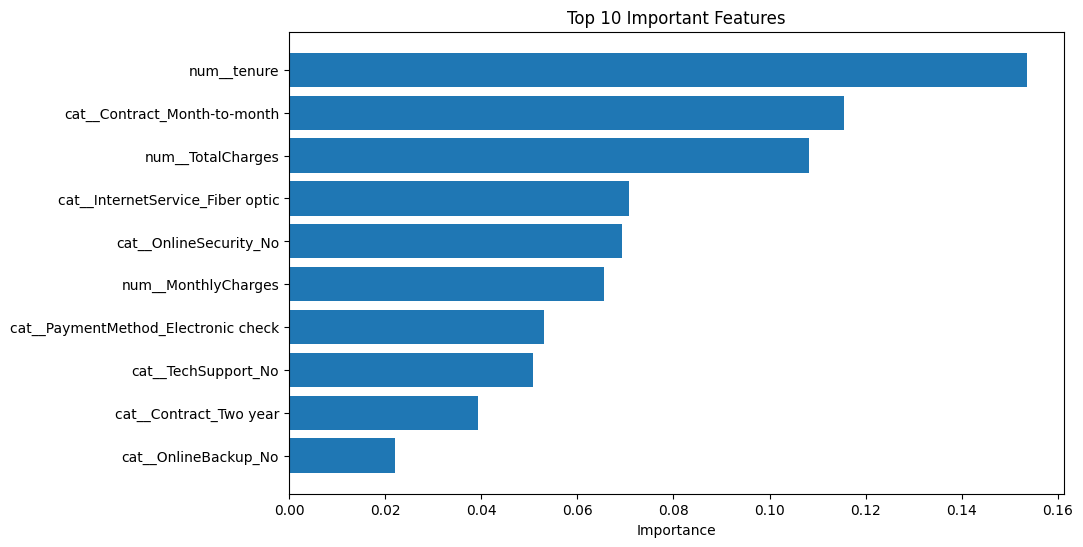

In [9]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.show()

In [10]:
import joblib
joblib.dump(rf_final, "../models/random_forest_churn.pkl")

['../models/random_forest_churn.pkl']

In [18]:
import pandas as pd
import joblib

# ===========================
# Load Saved Objects
# ===========================
preprocessor = joblib.load("../models/preprocessor.pkl")
model = joblib.load("../models/random_forest_churn.pkl")

# ===========================
# Create New Customer
# ===========================
new_customer = pd.DataFrame({
    "SeniorCitizen": [0],
    "tenure": [47],
    "MonthlyCharges": [68],
    "TotalCharges": [402.5],
    "gender": ["Female"],
    "Partner": ["No"],
    "Dependents": ["No"],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"]
})

# ===========================
# Preprocess the Customer Data
# ===========================
new_customer_processed = preprocessor.transform(new_customer)

# Convert processed data back to a DataFrame
feature_names = preprocessor.get_feature_names_out()

new_customer_processed = pd.DataFrame(
    new_customer_processed,
    columns=feature_names
)

# ===========================
# Make Prediction
# ===========================
prediction = model.predict(new_customer_processed)
probability = model.predict_proba(new_customer_processed)

# ===========================
# Display Results
# ===========================
print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Customer is likely to churn.")
else:
    print("Customer is likely to stay.")

print(f"Probability of Stay  : {probability[0][0]*100:.2f}%")
print(f"Probability of Churn : {probability[0][1]*100:.2f}%")

Prediction: 0
Customer is likely to stay.
Probability of Stay  : 50.60%
Probability of Churn : 49.40%
